In [8]:
import os, sys
import numpy as np
import pandas as pd
import pickle as pk
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib as mpl
from itertools import product
from scipy.optimize import curve_fit as cfit

sys.path.insert(0, '../scripts_analysis')
from analysis import *
from peaks import  detect_peaks
from util import *

plt.style.use('dark_background')
plt.rcParams.update(plt.rcParamsDefault)

simTypes = {
    'control':     dict(d='control', r='result.dat', v='vesData.dat'),
    'without cross-talk': dict(d='control_eachCa', r='sresult.dat', v='svesData.dat'),
    'syt7KO':      dict(d='syt7KO', r='result.dat', v='vesData.dat'),
    'nonsatBuffer': dict(d='control_unsatBuffer', r='result.dat', v='vesData.dat')
}
#print(simTypes)

resultPath = "../data/"
figPath = "../plots/mechanism/"
setupLoc = '../model_mcell'

designs = np.genfromtxt(os.path.join(setupLoc, 'representative_designs.txt'), dtype=str)
for i,d in enumerate(designs): print(i, d)

0 nVDCC_2_dVAZ_60_nAZ_15_RRP_35_ISI_20_nAP_10
1 nVDCC_3_dVAZ_100_nAZ_29_RRP_55_ISI_20_nAP_10
2 nVDCC_3_dVAZ_60_nAZ_9_RRP_20_ISI_20_nAP_10
3 nVDCC_3_dVAZ_80_nAZ_35_RRP_30_ISI_20_nAP_10
4 nVDCC_4_dVAZ_100_nAZ_19_RRP_50_ISI_20_nAP_10
5 nVDCC_4_dVAZ_120_nAZ_25_RRP_55_ISI_20_nAP_10
6 nVDCC_4_dVAZ_120_nAZ_33_RRP_50_ISI_20_nAP_10
7 nVDCC_4_dVAZ_80_nAZ_21_RRP_30_ISI_20_nAP_10
8 nVDCC_5_dVAZ_100_nAZ_11_RRP_50_ISI_20_nAP_10
9 nVDCC_5_dVAZ_120_nAZ_15_RRP_50_ISI_20_nAP_10
10 nVDCC_5_dVAZ_120_nAZ_23_RRP_40_ISI_20_nAP_10
11 nVDCC_5_dVAZ_120_nAZ_35_RRP_25_ISI_20_nAP_10
12 nVDCC_5_dVAZ_220_nAZ_35_RRP_50_ISI_20_nAP_10
13 nVDCC_5_dVAZ_80_nAZ_21_RRP_10_ISI_20_nAP_10
14 nVDCC_5_dVAZ_80_nAZ_29_RRP_10_ISI_20_nAP_10
15 nVDCC_6_dVAZ_140_nAZ_25_RRP_30_ISI_20_nAP_10
16 nVDCC_6_dVAZ_160_nAZ_19_RRP_55_ISI_20_nAP_10
17 nVDCC_6_dVAZ_160_nAZ_35_RRP_25_ISI_20_nAP_10
18 nVDCC_6_dVAZ_200_nAZ_29_RRP_50_ISI_20_nAP_10
19 nVDCC_6_dVAZ_80_nAZ_17_RRP_10_ISI_20_nAP_10
20 nVDCC_7_dVAZ_100_nAZ_33_RRP_5_ISI_20_nAP_10
21 nVDCC_7_

### Single AZ calcium domain

In [9]:
def get_conc_along_radius(simtype, tpoint, bins=np.arange(0,0.81,0.01), nseeds=500):
    df = pd.read_csv(os.path.join(resultPath, 'singleAZ', simtype, f'{tpoint:06.0f}.dat'), 
                     delimiter=' ', names=['x','y','z'])
    df['dist'] = np.sqrt(df['x']**2 + df['y']**2 + (df['z']+0.4)**2)

    # get count of ions in each shell
    counts, _ = np.histogram(df.dist, bins=bins)

    # get volume of each shell
    vol = np.zeros((len(counts)))
    for i in range(1,len(bins)):
        vol[i-1] = 2/3*np.pi*(bins[i]**3 - bins[i-1]**3)
        # print(bins[i], vol[i-1])

    # print(len(counts), len(_bins))

    return bins, counts/vol*0.00166/nseeds

bins, density = get_conc_along_radius('control', 2300)
# plt.plot(bins[5:], density[4:])

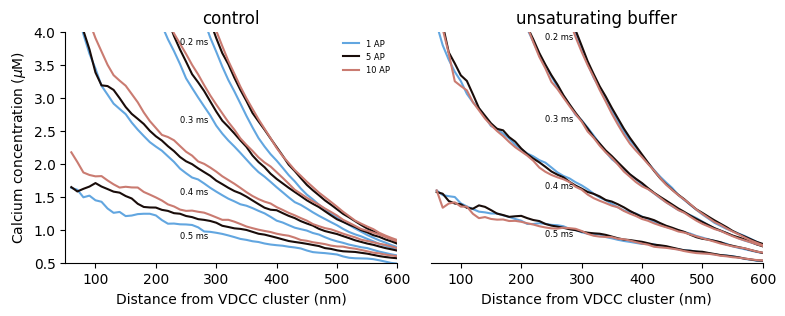

In [11]:
bins = np.arange(0,0.81,0.01)
stpoints = [2600, 82600, 182600]
tpoints = range(0, 301, 100)
APs = [1,5,10]
simtypes = {'control': 'control', 'unsaturating buffer': 'const_buffer'}#, 'no_buffer']

fig, axs = plt.subplots(1,len(simtypes), figsize=(9,3), sharex=True, sharey=True)
fig.subplots_adjust(wspace=0.1)
cmap = mpl.colormaps['berlin'] # 'viridis', 'managua', 'berlin'
lcolors = cmap(np.linspace(0.1, 0.9, len(stpoints)))

to_nm = 1000 # convert um to nm
for i,(key,simtype) in enumerate(simtypes.items()):
    for k,start in enumerate(stpoints):
        label = f'{APs[k]} AP'
        for j,tpoint in enumerate(tpoints):
            bins, density = get_conc_along_radius(simtype, start+tpoint, bins=bins)
            density = sp.signal.savgol_filter(density, 7, 3)
            axs[i].plot(bins[6:]*to_nm, density[5:], color=lcolors[k], label=label)
            label = None
            if not k:
                axs[i].text(bins[29]*to_nm-50, density[28]-0.1, f'{(tpoint+200)/1000:.1f} ms', fontsize=6)
    axs[i].set_title(key)
    axs[i].set_xlabel('Distance from VDCC cluster (nm)')

axs[0].set_ylabel(r'Calcium concentration ($\mu$M)')
axs[1].spines["left"].set_visible(False)
axs[0].legend(frameon=False, fontsize=6)
axs[1].tick_params(axis='y', size=0)
for ax in axs.ravel():
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xlim(50, 600)
    ax.set_ylim(0.5,4)

fig.savefig(os.path.join(figPath, 'ca_domain.svg'), dpi=300,
            bbox_inches='tight', transparent=True)
plt.show()

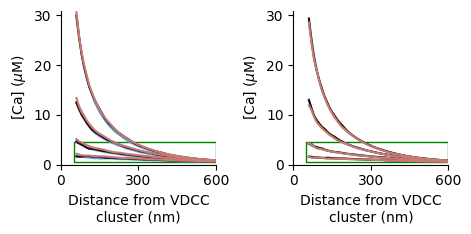

In [58]:
bins = np.arange(0,0.81,0.01)
stpoints = [2600, 82600, 182600]
tpoints = range(0, 301, 100)
APs = [1,5,10]
simtypes = {'control': 'control', 'const buffer conc.': 'const_buffer'}#, 'no_buffer']

fig, axs = plt.subplots(1,len(simtypes), figsize=(5,2), sharex=True)
fig.subplots_adjust(wspace=0.5)
cmap = mpl.colormaps['berlin'] # 'viridis', 'managua', 'berlin'
lcolors = cmap(np.linspace(0.1, 0.9, len(stpoints)))

for i,(key,simtype) in enumerate(simtypes.items()):
    for k,start in enumerate(stpoints):
        for j,tpoint in enumerate(tpoints):
            bins, density = get_conc_along_radius(simtype, start+tpoint, bins=bins)
            density = sp.signal.savgol_filter(density, 7, 3)
            axs[i].plot(bins[6:]*to_nm, density[5:], color=lcolors[k], label=label)

    axs[i].set_xlabel('Distance from VDCC\ncluster (nm)')

    ## make rectangle for zoomed in region
    rect = mpl.patches.Rectangle((50,0.5), 550, 4, linewidth=1, edgecolor='green', 
                                 facecolor='none')
    axs[i].add_patch(rect)

for ax in axs.ravel():
    ax.set_ylabel(r'[Ca] ($\mu$M)')
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xlim(0, 600)
    ax.set_ylim(0,31)
    ax.set_xticks([0, 300, 600])
    ax.set_yticks([0, 10, 20, 30])

fig.savefig(os.path.join(figPath, 'ca_domain_inset.svg'), dpi=300,
            bbox_inches='tight', transparent=True)
plt.show()

### Calcium overlap

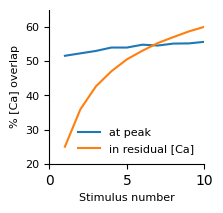

In [5]:
design = 'nVDCC_9_dVAZ_220_nAZ_31_RRP_15_ISI_20_nAP_10'
 
avg_peak_overlap, avg_basal_overlap = get_ca_overlap(design)

y_data = {
    'avg_peak_overlap': avg_peak_overlap, 
    'avg_basal_overlap': avg_basal_overlap
}

keys = ['avg_peak_overlap', 'avg_basal_overlap']

title_text = {'avg_peak_overlap': 'at peak',
              'avg_basal_overlap': 'in residual [Ca]'}

fig, ax = plt.subplots(1, sharex=True, figsize=(2,2))

for i, key in enumerate(keys):
    x = list(range(1,11))
    y = y_data[key]
    ax.plot(x, np.array(y)*100, label=title_text[key])#, color=cpall[j%22])

ax.set_xlim(0.8,10.1)
ax.set_xlabel('Stimulus number', fontsize=8)
ax.set_ylabel('% [Ca] overlap', fontsize=8)
ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(axis='y', labelsize=8)
    
ax.legend(frameon=False, fontsize=8)
ax.set_xlim(0,10)
ax.set_ylim(20,65)

plt.show()
fig.savefig(os.path.join(figPath, 'ca_overlap.svg'), dpi=300, 
            bbox_inches='tight', transparent=True)

### Calcium Signal

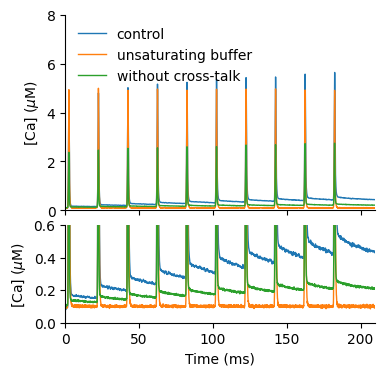

In [87]:
nAZ = int(getSimInfo(design, 'nAZ'))
_design = design.split('RRP')[0] + 'ISI' + design.split('ISI')[1]

## control
data_cont = pd.read_csv(os.path.join(dataPath, 'control', design, 'CaConc.dat'),
                    usecols=range(nAZ+1), sep='\t')
ca_cont = data_cont.iloc[:, 1:nAZ+1].mean(axis=1)

## unsaturating buffer
data_unsat = pd.read_csv(os.path.join(dataPath, 'control_unsatBuffer', design, 'CaConc.dat'),
                    usecols=range(nAZ+1), sep='\t')
ca_unsat = data_unsat.iloc[:, 1:nAZ+1].mean(axis=1)

## no cross-talk
data_cross = pd.read_csv(os.path.join(dataPath, 'control_eachCa', _design, 'CaConc.dat'), sep='\t')
ca_cross = data_cross.iloc[:, 2::4].mean(axis=1) + data_cross.iloc[:, 3::4].mean(axis=1)

fig, axs = plt.subplots(2, sharex=True, figsize=(4,4), gridspec_kw = {'height_ratios':[2,1]})
fig.subplots_adjust(hspace=0.1)

axs[0].plot(data_cont.iloc[:,0]*1000, ca_cont, linewidth=1, label='control')
axs[0].plot(data_unsat.iloc[:,0]*1000, ca_unsat, linewidth=1, label='unsaturating buffer')
axs[0].plot(data_cross.iloc[:,0]*1000, ca_cross, linewidth=1, label='without cross-talk')

axs[1].plot(data_cont.iloc[:,0]*1000, ca_cont, linewidth=1, label='control')
axs[1].plot(data_unsat.iloc[:,0]*1000, ca_unsat, linewidth=1, label='unsaturating buffer')
axs[1].plot(data_cross.iloc[:,0]*1000, ca_cross, linewidth=1, label='without cross-talk')

axs[0].legend(frameon=False)
axs[0].set_ylim(0,8)
axs[1].set_ylim(0,0.6)
axs[1].set_xlabel('Time (ms)')

for ax in axs.ravel():
    ax.set_ylabel(r'[Ca] ($\mu$M)')
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xlim(0, 210)
    # ax.set_ylim(0,31)
    # ax.set_xticks([0, 300, 600])
    # ax.set_yticks([0, 10, 20, 30])

fig.savefig(os.path.join(figPath, 'ca_signal.svg'), dpi=300,
            bbox_inches='tight', transparent=True)
plt.show()
plt.show()

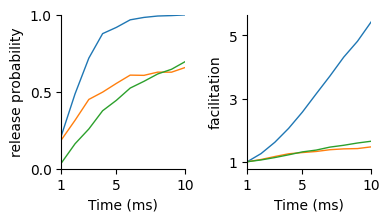

In [122]:
RRP = int(getSimInfo(design, 'RRP'))

## control
data_cont = pd.read_csv(os.path.join(dataPath, 'control', design, 'result.dat'),
                    usecols=['Pr', 'Rel'], sep='\t')
pr_cont = data_cont['Pr']
facil_cont = data_cont['Rel']*data_cont['Pr'][0]/data_cont['Pr']/data_cont['Rel'][0]

## unsaturating buffer
data_unsat = pd.read_csv(os.path.join(dataPath, 'control_unsatBuffer', design, 'result.dat'),
                    usecols=['Pr', 'Rel'], sep='\t')
pr_unsat = data_unsat['Pr']
facil_unsat = data_unsat['Rel']*data_unsat['Pr'][0]/data_unsat['Pr']/data_unsat['Rel'][0]

## no cross-talk
data_cross = pd.read_csv(os.path.join(dataPath, 'control_eachCa', _design, f'sresult_RRP_{RRP}.dat'),
                    usecols=['Pr', 'Rel'], sep='\t')
pr_cross = data_cross['Pr']
facil_cross = data_cross['Rel']*data_cross['Pr'][0]/data_cross['Pr']/data_cross['Rel'][0]

fig, axs = plt.subplots(1,2, sharex=True, figsize=(4,2))
fig.subplots_adjust(wspace=0.5)
x = list(range(1,11))
axs[0].plot(x, pr_cont, linewidth=1, label='control')
axs[0].plot(x, pr_unsat, linewidth=1, label='unsaturating buffer')
axs[0].plot(x, pr_cross, linewidth=1, label='without cross-talk')
axs[1].plot(x, facil_cont, linewidth=1, label='control')
axs[1].plot(x, facil_unsat, linewidth=1, label='unsaturating buffer')
axs[1].plot(x, facil_cross, linewidth=1, label='without cross-talk')

axs[0].set_ylim(0,1)
axs[0].set_ylabel(r'release probability')
axs[0].set_yticks([0,0.5,1])

# axs[1].legend(frameon=False)
# axs[1].set_ylim(1,6)
axs[1].set_ylabel(r'facilitation')
axs[1].set_yticks([1,3,5])



for ax in axs.ravel():
    ax.set_xlabel('Time (ms)')
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xlim(1, 10)
    ax.set_xticks([1,5,10])

plt.show()
fig.savefig(os.path.join(figPath, 'facilitation.svg'), dpi=300, 
            bbox_inches='tight', transparent=True)

## Distribution of facilitation

In [5]:
def get_fig_handle(nX=3, nY=4, sharex=True, figsize=(8,7)):
    f, axs = plt.subplots(nX, nY, sharex=sharex, figsize=figsize)
    f.subplots_adjust(wspace=0.05, hspace=0.06)
         
    axs[2,2].set_xlabel('Stimulus Number', fontsize=9)

    axs[0,0].set_ylabel('Release Probability', fontsize=9)
    axs[0,0].axes.yaxis.set_visible(True)
    axs[0,0].spines["left"].set_visible(True)
    axs[0,0].tick_params(axis=u'y', which=u'both', length=2)

    axs[1,0].spines["left"].set_visible(True)
    axs[1,0].set_ylabel('nRel', fontsize=9)
    #axs[1,0].set_yticks(range(1,11,2))
    axs[1,0].tick_params(axis=u'y', which=u'both', length=2)
    axs[1,0].axes.yaxis.set_visible(True)

    axs[2,0].axes.yaxis.set_visible(True)
    axs[2,0].spines["left"].set_visible(True)
    # axs[2,0].set_ylabel(r'Facilitation $\left(\frac{nRel_n}{nRel_1}\right)$', fontsize=9)
    axs[2,0].set_ylabel(r'Facilitation', fontsize=9)
    axs[2,0].tick_params(axis=u'y', which=u'both', length=2)
        
    # axs[0,0].text(-2.5, 1, 'a', fontsize=12)
    # axs[1,0].text(-2.5, 8.5, 'b', fontsize=12)
    #axs[2,0].text(-2.5, 28, 'c', fontsize=12);

    for ax in [item for axi in axs for item in axi]:
        ax.spines["right"].set_visible(False)
        ax.spines["top"].set_visible(False)
        ax.spines["left"].set_visible(False)
        ax.tick_params(axis=u'both', which=u'both', length=0, direction='in', labelsize=8)
        ax.axes.yaxis.set_visible(False)
        ax.set_xticks((1,4,7,10))
        ax.set_xlim(0.9, 10.1)
        #axis.tick_params(axis=u'both', which=u'both',length=2)

    return f, axs

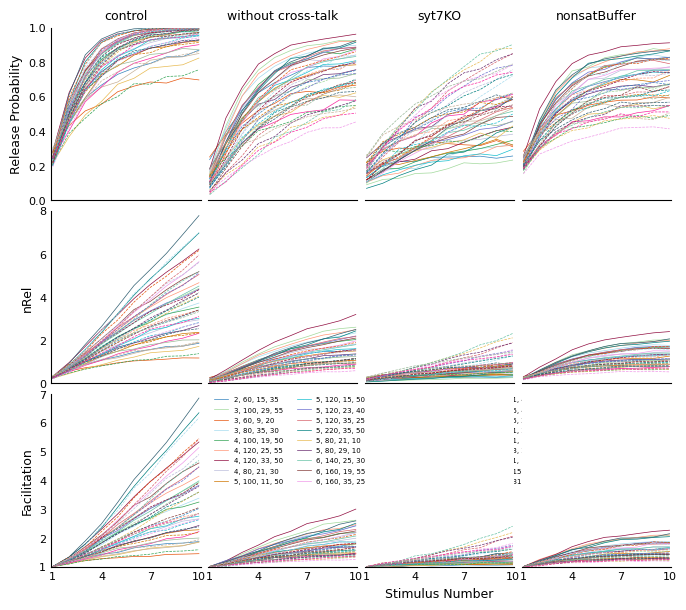

In [21]:
f, axs = get_fig_handle(3,4)

ls = ['-', '--']
lw = 0.5
for i,d in enumerate(designs[:]):
    label = str([int(a) for a in re.findall(r'\d+', d)[:-2]])[1:-1]
    # label=f'{cdiv[nv]},  {cdiv[dv]},  {cdiv[naz]},  {cdiv[rrp]}'

    # print(label)

    for j,(stlabel,stinfo) in enumerate(simTypes.items()):
        st = stinfo['d']
        strf = stinfo['r']
        stvf = stinfo['v']

        if stlabel == 'without cross-talk':
            RRP = int(getSimInfo(d, 'RRP'))
            dd = d.split('RRP')[0] + 'ISI' + d.split('ISI')[1]
            strff = strf.split('.')[0] + f'_RRP_{RRP}.dat'
            data = pd.read_csv(os.path.join(resultPath, st, dd, strff), usecols=['Pr', 'Rel'], sep='\t') # 'results' file
        else:
            data = pd.read_csv(os.path.join(resultPath, st, d, strf), usecols=['Pr', 'Rel'], sep='\t')  # 'results' file
    
        y_data = {
            'pr': data['Pr'], 
            'rel': data['Rel'], 
            'mvu': data['Rel']/data['Pr'], 
            'facil': data['Rel']*data['Pr'][0]/data['Pr']/data['Rel'][0]
        }        
        
        # if stlabel == 'without cross-talk':
        #     RRP = int(getSimInfo(d, 'RRP'))
        #     dd = d.split('RRP')[0] + 'ISI' + d.split('ISI')[1]
        #     strff = strf.split('.')[0] + f'_RRP_{RRP}.dat'
        #     prData = np.genfromtxt(os.path.join(resultPath, st, dd, strff), unpack=True, skip_header=1) # `results` file
        # else:
        #     prData = np.genfromtxt(os.path.join(resultPath, st, d, strf), unpack=True, skip_header=1) # `results` file
    

        ## Release Probability
        axs[0,j].plot(range(1,11), y_data['pr'], lw=lw, linestyle=ls[i//22], color=cpall[i%22], 
                        label=label)
        axs[0,j].set_ylim(0,1)
        axs[0,j].set_title(stlabel, fontsize=9)

        ## Total Releases (nRel)
        axs[1,j].plot(range(1,11), y_data['rel'], lw=lw, linestyle=ls[i//22], color=cpall[i%22], 
                        label=label)
        axs[1,j].set_ylim(0,8)
        
        ## Facilitation
        axs[2,j].plot(range(1,11), y_data['facil'], lw=lw, linestyle=ls[i//22], color=cpall[i%22], label=label)
        axs[2,j].set_ylim(1,7)
    
for ax in axs[:,0]:
    ax.spines["left"].set_visible(True)
    ax.axes.yaxis.set_visible(True)

axs[-1,1].legend(frameon=False, ncol=5, handlelength=2, fontsize=5,
                 loc='upper left', bbox_to_anchor=(0, 1.02), labelspacing=0.6)

plt.savefig(os.path.join(figPath, 'facilitation.pdf'), dpi=300, bbox_inches='tight', transparent=True)
plt.show()

## Change in Pr, nRel, Facilitation ($nRel_{10} / nRel_1$)

In [ ]:
lw = 0.3
allprData = []
for d in tempdirs:
    temp = []
    for stlabel,stinfo in simTypes.items():
        st = stinfo['d']
        strf = stinfo['r']
        
        prFile = os.path.join(resultPath, st, d, strf)
        pr = np.genfromtxt(prFile, usecols=(0), unpack=True)[0]
        nRel = np.genfromtxt(prFile, usecols=(2), unpack=True)
        temp.append([pr, nRel[-1], nRel[-1]/nRel[0]])
    temp = np.array(temp)
    #print(temp.shape)
    allprData.append(temp)
    
allprData = np.array(allprData)
for i in range(allprData.shape[-1]):
    allprData[:,:,i] = allprData[:,:,i][allprData[:,:,i][:,0].argsort()]

## p-values
'''for i in range(allprData.shape[-1]):
    print(sp.stats.ttest_rel(allprData[:,0,i], allprData[:,1,i]))
    print(sp.stats.ttest_rel(allprData[:,0,i], allprData[:,2,i]))
    print(sp.stats.ttest_rel(allprData[:,0,i], allprData[:,3,i]))
    print(sp.stats.ttest_rel(allprData[:,0,i], allprData[:,4,i]),'\n')
'''
#print(allprData.shape, '\n', allprData[:,-1,0])

Text(-2, 29, 'f')

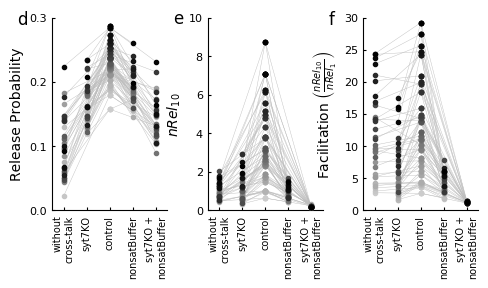

In [28]:
cpp = cm.get_cmap('binary', 256)
cp = cpp(np.linspace(0.2, 1, 33))

f, ax = plt.subplots(1, 3, sharex=True, figsize=(5.5,2.5))
f.subplots_adjust(wspace=0.35, hspace=0.0)

xlabel = ['without\ncross-talk', 'syt7KO', 'control', 'nonsatBuffer', 'syt7KO +\nnonsatBuffer']
for axis in ax:
    axis.spines["right"].set_visible(False)
    axis.spines["top"].set_visible(False)
    axis.tick_params(axis=u'both', which=u'both', length=2, direction='in', labelsize=8)
    axis.set_xticks(range(5))
    axis.set_xlim(-0.5,4.5)
    axis.set_xticklabels(xlabel, rotation=90, va='center', ha='right', fontsize=7, rotation_mode='anchor')

## allpr:: control:0, without crosstalk:1, syt7KO:2
## unsatBuffer:3, control + unsatBuffer:4
for i,allprs in enumerate(allprData):
    #print(allprs.T)
    #allprs = allprs.T[allprs.T[:,2].argsort()]
    for j,allpr in enumerate(allprs.T):
        ax[j].plot([2,0], allpr[[0,1]], 'o', ms=3, lw=lw, color=cp[i], zorder=9)
        ax[j].plot([2,0], allpr[[0,1]], '-', lw=lw, color=cpall[-3])

        ax[j].plot([2,1], allpr[[0,2]], 'o', ms=3, lw=lw, color=cp[i], zorder=9)
        ax[j].plot([2,1], allpr[[0,2]], '-', lw=lw, color=cpall[-3])

        ax[j].plot([2,3], allpr[[0,3]], 'o', ms=3, lw=lw, color=cp[i], zorder=9)
        ax[j].plot([2,3], allpr[[0,3]], '-', lw=lw, color=cpall[-3])

        ax[j].plot([2,4], allpr[[0,4]], 'o', ms=3, lw=lw, color=cp[i], zorder=9)
        ax[j].plot([2,4], allpr[[0,4]], '-', lw=lw, color=cpall[-3])
 
'''
a=0.2
ax.scatter([2], np.mean(allprData,axis=0)[0], s=500, marker='_', color=cpall[-1], zorder=10)
ax.scatter([0], np.mean(allprData,axis=0)[1], s=500, marker='_', color='w', zorder=10)
ax.scatter([1], np.mean(allprData,axis=0)[2], s=500, marker='_', color='w', zorder=10)
ax.scatter([3], np.mean(allprData,axis=0)[3], s=500, marker='_', color='w', zorder=10)
ax.scatter([4], np.mean(allprData,axis=0)[4], s=500, marker='_', color='w', zorder=10)
'''

ax[0].set_ylim(0,0.3)
ax[0].set_yticks([0, 0.1, 0.2, 0.3])
ax[0].set_ylabel('Release Probability', fontsize=10)
ax[0].text(-2, 0.29, 'd', fontsize=12)

ax[1].set_ylim(0,10)
ax[1].set_ylabel(r'$nRel_{10}$', fontsize=10)
ax[1].text(-2, 9.7, 'e', fontsize=12)

ax[2].set_ylim(0,30)
ax[2].set_ylabel(r'Facilitation $\left(\frac{nRel_{10}}{nRel_1}\right)$', fontsize=10)
ax[2].text(-2, 29, 'f', fontsize=12)

#plt.savefig(os.path.join(figPath, 'change.eps'), fmt='eps', dpi=300, bbox_inches='tight', transparent=True)

## L-M-H 4D plot for facilitation $(nRel_{10}/nRel_1$)

In [13]:
dVDCCr = dict(low=[60, 100],
              mid=[120, 160],
              high=[180, 220])

nVDCCr = dict(low=[2, 4],
              mid=[7, 9],
              high=[12, 14])

nAZr  = dict(low=[7, 10],
             mid=[17, 20],
             high=[26, 29])

RRPr  = dict(low=[5, 15],
             mid=[20, 25],
             high=[30, 40])
'''
nVDCCr = dict(low=[2, 5],
              mid=[6, 10],
              high=[11, 14])

dVDCCr = dict(low=[60, 110],
              mid=[120, 160],
              high=[170, 220])

nAZr  = dict(low=[7, 14],
             mid=[15, 21],
             high=[24, 29])

RRPr  = dict(low=[5, 16],
             mid=[17, 28],
             high=[29, 40])
#'''
i=1

# nV dV nAZ RRP
ct = {
    'low': 0,
    'mid': 1,
    'high': 2
}
ncases = np.zeros((3,3,3,3))
for d in tempdirs:
    nv  = int(getSimInfo(d, 'nVDCC'))
    dv  = int(getSimInfo(d, 'dVDCC'))
    naz  = int(getSimInfo(d, 'nAZ'))
    rrp = int(getSimInfo(d, 'RRP'))
    #print(nv, dv, naz, rrp)
    
    for k, r in nVDCCr.items():
        if nv>=r[0] and nv<=r[1]:
            nvk = k
            continue
            
    for k, r in dVDCCr.items():
        if dv>=r[0] and dv<=r[1]:
            dvk = k
            continue
            
    for k, r in nAZr.items():
        if naz>=r[0] and naz<=r[1]:
            nazk = k
            continue
            
    for k, r in RRPr.items():
        if rrp>=r[0] and rrp<=r[1]:
            rrpk = k
            continue
    
    #print(ct[nvk], ct[dvk], ct[nazk], ct[rrpk], '\n')
    prFile = os.path.join(resultPath, 'control_eachCa', d, 'aresult.dat')
    prs = np.genfromtxt(prFile, usecols=(2), unpack=True)
    ncases[ct[nvk], ct[dvk], ct[nazk], ct[rrpk]] = prs[-1]/prs[0]
#print(ncases)

#with open(os.path.join(resultPath, simTypes['control']['d'], 'f_Pr_4D.dat'), "wb") as outfile:
#    pk.dump(ncases, outfile)

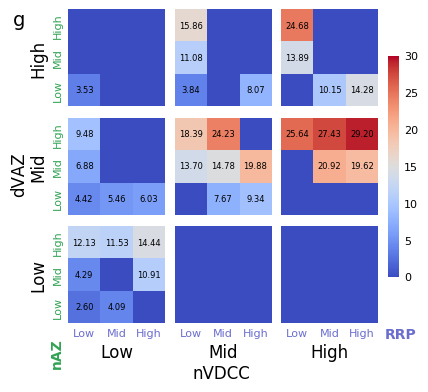

In [14]:
f, ax = plt.subplots(3, 3, sharex=True, sharey=True, figsize=(5,4.1))
f.subplots_adjust(wspace=0.1, hspace=0.1)

#infile = os.path.join(resultPath, simTypes['control']['d'], 'f_nRel_4D.dat')
#with open(infile, "rb") as inf:
#    ncases = pk.load(inf)
cases = ['Low', 'Mid', 'High']

for axis in ax[-1,:]:
    axis.set_xticks(range(3))
    axis.set_xticklabels(cases, color=cpdark[5], fontsize=8)

for axis in ax[:,0]:
    axis.set_yticks(range(3))
    axis.set_yticklabels(cases, color=cpdark[2], fontsize=8,
                         rotation=90, ha="right", va="center")

for nv, dv in product(range(3), range(3)):
    ax[nv][dv].tick_params(axis=u'both', which=u'both',length=0)
    
    imdata = ncases[2-nv, dv]
    im = ax[nv][dv].imshow(imdata, vmin=0, vmax=np.ceil(np.max(ncases)), 
                           cmap='coolwarm', origin='lower')
    for i in range(3):
        for j in range(3):
            if imdata[i, j] > 0.01:
                text = ax[nv][dv].text(j, i, f'{imdata[i, j]:0.2f}', fontsize=6,
                                       ha="center", va="center", color="black")
    if nv==2:
        ax[nv][dv].set_xlabel(cases[dv], fontsize=12)
    if dv==0:
        ax[nv][dv].set_ylabel(cases[2-nv], fontsize=12)
       
    ax[nv][dv].spines["bottom"].set_visible(False)
    ax[nv][dv].spines["top"].set_visible(False)
    ax[nv][dv].spines["right"].set_visible(False)
    ax[nv][dv].spines["left"].set_visible(False)
    
ax[-1,0].text(-1.05, -1.8, 'nAZ', size=10, rotation=90, color=cpdark[2], fontweight='bold')
ax[-1,-1].text(2.7, -0.96, 'RRP', size=10, color=cpdark[5], fontweight='bold')
ax[-1,1].text(0.05, -2.2, 'nVDCC', size=12, color=cpdark[-1])
ax[1,0].text(-2.3, 0.2, 'dVAZ', size=12, rotation=90, color=cpdark[-1])
ax[0,0].text(-2.2, 2, 'g', fontsize=14)

cb = f.colorbar(im, ax=ax.ravel().tolist(), shrink=0.7, anchor=(-0.2,0.5))
cb.outline.set_visible(False)
cb.ax.tick_params(size=0, labelsize=8)

f.savefig(os.path.join(figPath, 'facilitation_4D.eps'), fmt='eps',
          dpi=300, bbox_inches='tight', transparent=True)

## Correlation between density of state for Pr ~ 0.2 and Facilitation

## Facilitation for different simulation conditions $(\frac{nRel_n}{nRel_1})$

<string>:6: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray


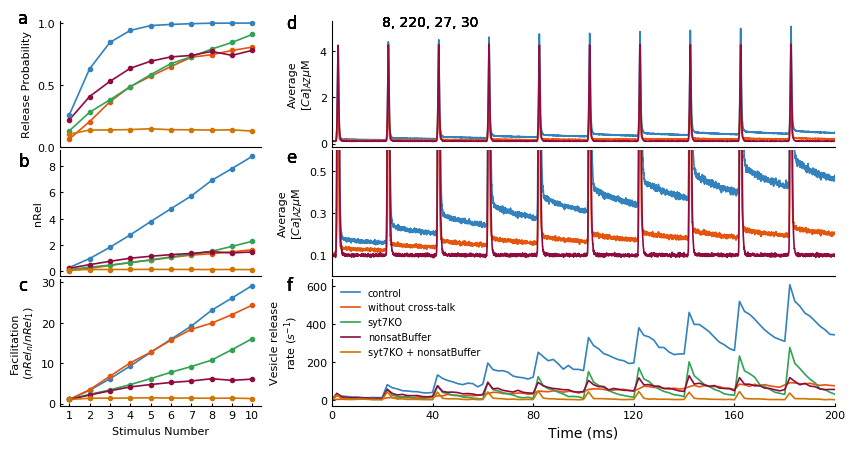

In [22]:
lw = 1.2
tscale = 1e3
lsize = 8
for d in dirs[17:18]:
    f, ax = plt.subplots(3, 2, figsize=(10,5), gridspec_kw={'width_ratios': [2, 5]})
    f.subplots_adjust(wspace=0.2, hspace=0.02)
    for axis in ax.ravel():
        axis.spines["right"].set_visible(False)
        axis.spines["top"].set_visible(False)
        #axis.spines["bottom"].set_visible(False)
        axis.tick_params(axis=u'y', which=u'both', length=2, direction='in', labelsize=8)
        axis.tick_params(axis=u'x', which=u'both', length=0, direction='in', labelsize=8)
        axis.axes.xaxis.set_visible(False)

    nAZ = int(getSimInfo(d, 'nAZ'))
    
    for i,(stlabel,stinfo) in enumerate(simTypes.items()):
        st = stinfo['d']
        strf = stinfo['r']
        stvf = stinfo['v']
        
        prFile = os.path.join(resultPath, st, d, strf)
        prData = np.genfromtxt(prFile, unpack=True)
        nStim = prData.shape[1]
        stim = np.arange(1,nStim+1)
        
        ## Pr
        ax[0,0].errorbar(stim, prData[0], yerr=prData[1], color=cpdark[i], fmt='.', elinewidth=2, capsize=0)
        ax[0,0].plot(range(1,nStim+1), prData[0], lw=lw, color=cpdark[i], label=stlabel)
        ax[0,0].set_ylim(0,1.02)
        ax[0,0].set_ylabel('Release Probability', fontsize=lsize)
        ax[0,0].set_yticks([0, 0.5, 1])
        #ax[0,0].legend(loc='lower right', bbox_to_anchor=(1.3, 0.2), ncol=1, borderaxespad=0, frameon=False)
        ax[0,0].text(-1.5, 1., 'a', fontsize=12)

        ## nRel
        ax[1,0].errorbar(stim, prData[2], yerr=prData[3], color=cpdark[i], fmt='.', elinewidth=2, capsize=0)
        ax[1,0].plot(range(1,nStim+1), prData[2], lw=lw, color=cpdark[i])
        ax[1,0].set_ylabel('nRel', fontsize=lsize)
        ax[1,0].text(-1.5, 8, 'b', fontsize=12)
        
        ## Facilitation (nRel)
        ax[2,0].errorbar(stim, prData[2]/prData[2][0], yerr=prData[3]/prData[2][0], color=cpdark[i], 
                         fmt='.', elinewidth=2, capsize=0)
        ax[2,0].plot(range(1,nStim+1), prData[2]/prData[2][0], lw=lw, color=cpdark[i])
        ax[2,0].set_xticks(range(1, 11))
        ax[2,0].set_ylabel('Facilitation\n$(nRel_n / nRel_1)$', fontsize=lsize)
        ax[2,0].set_xlabel('Stimulus Number', fontsize=lsize)
        ax[2,0].text(-1.5, 28, 'c', fontsize=12)
        
        ## Average Calcium Trace
        if st == 'control_eachCa':
            cadata = []
            for naz in range(1,nAZ+1):
                fname = f'CaConc_AZ_{naz}.dat'
                if stlabel == 'control': ii=2
                elif stlabel == 'without cross-talk': ii=1
                cadata.append(np.genfromtxt(os.path.join(resultPath, st, d, fname), 
                                            usecols=(0,ii), unpack=True))
            cadata = np.mean(np.array(cadata), axis=0)
            ax[0,1].plot(cadata[0]*tscale, cadata[1], lw=lw, color=cpdark[i])
        elif st == 'control_unsatBuffer':
            cadata = np.genfromtxt(os.path.join(resultPath, st, d, 'CaConc.dat'), unpack=True)
            cadata = np.array([cadata[0], np.mean(cadata[1:nAZ+1], axis=0)])
            ax[0,1].plot(cadata[0]*tscale, cadata[1], lw=lw, color=cpdark[i])
        ax[0,1].set_ylabel('Average\n$[Ca]_{AZ} \mu$M', fontsize=lsize)
        ax[0,1].text(-18, 5, 'd', fontsize=12)
        ax[0,1].text(20, 5.1, str([int(a) for a in re.findall(r'\d+', d)[:-2]])[1:-1], size=10)
        
        ## Average Basal Calcium Trace
        if st == 'control_eachCa' or st == 'control_unsatBuffer':
            ax[1,1].plot(cadata[0]*tscale, cadata[1], lw=lw, color=cpdark[i])            
        ax[1,1].set_ylabel('Average\n$[Ca]_{AZ} \mu$M', fontsize=lsize)
        ax[1,1].set_ylim(0,0.6)
        ax[1,1].set_yticks([0.1, 0.3, 0.5])
        ax[1,1].text(-18, 0.54, 'e', fontsize=12)
                
        ## Vesicle Release Histogram
        inf = os.path.join(resultPath, st, d, stvf)

        with open(inf, "rb") as infile:
            vesData = pk.load(infile)

        seeds = len(vesData['AZ1']['sync'])
        #print(seeds)

        df = pd.io.json.json_normalize(vesData, sep='_')
        df = df.to_dict(orient='records')[0]

        emptyKeys = []
        for k,v in df.items():
            if all([not a for a in v]):
                emptyKeys.append(k)

        for e in emptyKeys:
            df.pop(e)

        vTimes = np.sort(np.concatenate(np.concatenate(list(df.values())))) # times of all the releases

        bindt = 0.002
        #print(cadata[0])
        bins = np.arange(0, cadata[0][-1], bindt)
        n, bins = np.histogram(vTimes, bins)#, rwidth=0.9, color=cpallb[i])
        vrate = n/(seeds*bindt)
        vratet = bins[:-1]
        ax[2,1].plot(vratet*tscale, vrate, lw=lw, color=cpdark[i], label=stlabel)
        ax[2,1].legend(frameon=False, fontsize=7)
        
        ax[2,1].set_ylabel('Vesicle release\nrate ($s^{-1}$)', fontsize=lsize)
        ax[2,1].set_xlabel('Time (ms)')
        ax[2,1].text(-18, 580, 'f', fontsize=12)
        #ax[2,1].set_xtics(range(1,11,2))
    
    for axis in ax[:,1]:
        axis.set_xlim(0, 200)
        axis.set_xticks(range(0, 201, 40))
        
    for axis in ax[-1,:]:
        axis.axes.xaxis.set_visible(True)
        axis.tick_params(axis=u'x', length=2)

    plt.savefig(os.path.join(figPath, f'{d}.eps'), fmt='eps', 
                dpi=300, bbox_inches='tight', transparent=True)

In [ ]:
## Vesicle Release Histogram
inf = os.path.join(resultPath, 'control_eachCa', dirs[17:18], 'avesData.dat')

with open(inf, "rb") as infile:
    vesData = pk.load(infile)

seeds = len(vesData['AZ1']['sync'])
#print(seeds)

df = pd.io.json.json_normalize(vesData, sep='_')
df = df.to_dict(orient='records')[0]

emptyKeys = []
for k,v in df.items():
    if all([not a for a in v]):
        emptyKeys.append(k)

for e in emptyKeys:
    df.pop(e)

ks = df.keys()
asyncRel = []
syncRel = []
for k in list(ks)[:]:
    if '_async' in k:
        asyncRel.append(np.concatenate(list(df[k])))
    if '_sync' in k:
        syncRel.append(np.concatenate(list(df[k])))
        
asyncRel = np.concatenate(asyncRel)
syncRel = np.concatenate(syncRel)

# Contribution of indivudual components in facilitation

## syt7

In [21]:
dVDCCr = dict(low=[60, 100],
              mid=[120, 160],
              high=[180, 220])

nVDCCr = dict(low=[2, 4],
              mid=[7, 9],
              high=[12, 14])

nAZr  = dict(low=[7, 10],
             mid=[17, 20],
             high=[26, 29])

RRPr  = dict(low=[5, 15],
             mid=[20, 25],
             high=[30, 40])
'''
nVDCCr = dict(low=[2, 5],
              mid=[6, 10],
              high=[11, 14])

dVDCCr = dict(low=[60, 110],
              mid=[120, 160],
              high=[170, 220])

nAZr  = dict(low=[7, 14],
             mid=[15, 21],
             high=[24, 29])

RRPr  = dict(low=[5, 16],
             mid=[17, 28],
             high=[29, 40])
#'''
i=1

# nV dV nAZ RRP
ct = {
    'low': 0,
    'mid': 1,
    'high': 2
}
ncases = np.zeros((3,3,3,3))
for d in tempdirs:
    nv  = int(getSimInfo(d, 'nVDCC'))
    dv  = int(getSimInfo(d, 'dVDCC'))
    naz  = int(getSimInfo(d, 'nAZ'))
    rrp = int(getSimInfo(d, 'RRP'))
    #print(nv, dv, naz, rrp)
    
    for k, r in nVDCCr.items():
        if nv>=r[0] and nv<=r[1]:
            nvk = k
            continue
            
    for k, r in dVDCCr.items():
        if dv>=r[0] and dv<=r[1]:
            dvk = k
            continue
            
    for k, r in nAZr.items():
        if naz>=r[0] and naz<=r[1]:
            nazk = k
            continue
            
    for k, r in RRPr.items():
        if rrp>=r[0] and rrp<=r[1]:
            rrpk = k
            continue
    
    #print(ct[nvk], ct[dvk], ct[nazk], ct[rrpk], '\n')
    prFile = os.path.join(resultPath, 'control_unsatBuffer', d, 'result.dat')
    prs = np.genfromtxt(prFile, usecols=(2), unpack=True)
    ncases[ct[nvk], ct[dvk], ct[nazk], ct[rrpk]] = prs[-1]/prs[0]
#print(ncases)

#with open(os.path.join(resultPath, simTypes['control']['d'], 'f_Pr_4D.dat'), "wb") as outfile:
#    pk.dump(ncases, outfile)

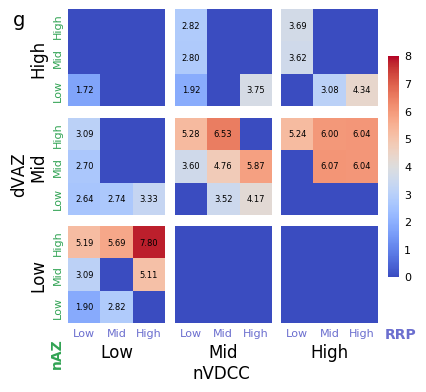

In [20]:
f, ax = plt.subplots(3, 3, sharex=True, sharey=True, figsize=(5,4.1))
f.subplots_adjust(wspace=0.1, hspace=0.1)

#infile = os.path.join(resultPath, simTypes['control']['d'], 'f_nRel_4D.dat')
#with open(infile, "rb") as inf:
#    ncases = pk.load(inf)
cases = ['Low', 'Mid', 'High']

for axis in ax[-1,:]:
    axis.set_xticks(range(3))
    axis.set_xticklabels(cases, color=cpdark[5], fontsize=8)

for axis in ax[:,0]:
    axis.set_yticks(range(3))
    axis.set_yticklabels(cases, color=cpdark[2], fontsize=8,
                         rotation=90, ha="right", va="center")

for nv, dv in product(range(3), range(3)):
    ax[nv][dv].tick_params(axis=u'both', which=u'both',length=0)
    
    imdata = ncases[2-nv, dv]
    im = ax[nv][dv].imshow(imdata, vmin=0, vmax=np.ceil(np.max(ncases)), 
                           cmap='coolwarm', origin='lower')
    for i in range(3):
        for j in range(3):
            if imdata[i, j] > 0.01:
                text = ax[nv][dv].text(j, i, f'{imdata[i, j]:0.2f}', fontsize=6,
                                       ha="center", va="center", color="black")
    if nv==2:
        ax[nv][dv].set_xlabel(cases[dv], fontsize=12)
    if dv==0:
        ax[nv][dv].set_ylabel(cases[2-nv], fontsize=12)
       
    ax[nv][dv].spines["bottom"].set_visible(False)
    ax[nv][dv].spines["top"].set_visible(False)
    ax[nv][dv].spines["right"].set_visible(False)
    ax[nv][dv].spines["left"].set_visible(False)
    
ax[-1,0].text(-1.05, -1.8, 'nAZ', size=10, rotation=90, color=cpdark[2], fontweight='bold')
ax[-1,-1].text(2.7, -0.96, 'RRP', size=10, color=cpdark[5], fontweight='bold')
ax[-1,1].text(0.05, -2.2, 'nVDCC', size=12, color=cpdark[-1])
ax[1,0].text(-2.3, 0.2, 'dVAZ', size=12, rotation=90, color=cpdark[-1])
ax[0,0].text(-2.2, 2, 'g', fontsize=14)

cb = f.colorbar(im, ax=ax.ravel().tolist(), shrink=0.7, anchor=(-0.2,0.5))
cb.outline.set_visible(False)
cb.ax.tick_params(size=0, labelsize=8)

f.savefig(os.path.join(figPath, 'facilitation_control_unsatBuffer_4D.eps'), fmt='eps',
          dpi=300, bbox_inches='tight', transparent=True)

# vesicle release from artificial calcium concentration

In [60]:
## Vesicle Release Histogram
inf = os.path.join(resultPath, 'control_eachCa', dirs[17], 'avesData.dat')

with open(inf, "rb") as infile:
    vesData = pk.load(infile)

seeds = len(vesData['AZ1']['sync'])
#print(seeds)

df = pd.io.json.json_normalize(vesData, sep='_')
df = df.to_dict(orient='records')[0]

emptyKeys = []
for k,v in df.items():
    if all([not a for a in v]):
        emptyKeys.append(k)

for e in emptyKeys:
    df.pop(e)

ks = df.keys()
asyncRel = []
syncRel = []
for k in list(ks)[:]:
    if '_async' in k:
        asyncRel.append(np.concatenate(list(df[k])))
    if '_sync' in k:
        syncRel.append(np.concatenate(list(df[k])))
        
asyncRel = np.concatenate(asyncRel)
syncRel = np.concatenate(syncRel)

cadata = []
for naz in range(1,nAZ+1):
    fname = f'CaConc_AZ_{naz}.dat'
    cadata.append(np.genfromtxt(os.path.join(resultPath, 'control_eachCa', dirs[17], fname), 
                                usecols=(0,2), unpack=True))
cadata = np.mean(np.array(cadata), axis=0)

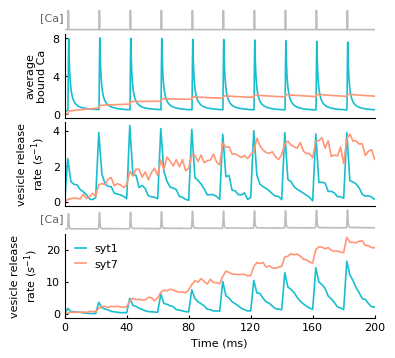

In [72]:
lw = 1.2
tscale = 1e3
f, ax = plt.subplots(5, sharex=True, figsize=(4,4), gridspec_kw={'height_ratios':[1,4,4,1,4]})
f.subplots_adjust(wspace=0.0, hspace=0.06)
for axis in ax:
    axis.spines["right"].set_visible(False)
    axis.spines["top"].set_visible(False)
    axis.tick_params(axis=u'x', which=u'both', length=0, direction='in', labelsize=8)
    axis.tick_params(axis=u'y', which=u'both', length=2, direction='in', labelsize=8)

resCa = 0.3

### Ca Plot
dart = f'resCa_{resCa}_RRP_10'
dreal = 'nVDCC_9_dVDCC_140_nAZ_19_RRP_10_ISI_20_nAP_10'
inf = os.path.join(resultPath, 'control_eachCa', dart, 'CaConc.dat')
CaData = np.genfromtxt(inf, unpack=True)
ax[0].plot(CaData[0]*tscale, CaData[1], lw=lw, color=cpall[-3])
ax[0].set_xlim(0, 200)
ax[0].text(-16, 4, '[Ca]', fontsize=8, color=cpall[-4])
ax[0].spines["left"].set_visible(False)
ax[0].axes.yaxis.set_visible(False)
ax[0].spines["bottom"].set_visible(False)


### AZ plot
inf = os.path.join(resultPath, 'control_eachCa', dart, 'AZ.dat')
azData = np.genfromtxt(inf, unpack=True)
#print(azData.shape)

# syt1
azsyncf = zip([2,8,14,3,9,15,4,10,16,5,11,17,6,12,18], [1,1,1,2,2,2,3,3,3,4,4,4,5,5,5])
azcasync = np.sum(np.array([azData[i]*j for i,j in azsyncf]), axis=0)

# syt7
azasyncf = zip(range(7,19), [1]*6+[2]*6)
azcaasync = np.sum(np.array([azData[i]*j for i,j in azasyncf]), axis=0)

ax[1].plot(azData[0]*tscale, azcasync, lw=lw, color=cppaired[1], label='syt1')
ax[1].plot(azData[0]*tscale, azcaasync, lw=lw, color=cppaired[3], label='syt7')
ax[1].set_ylabel('average\nbound Ca', fontsize=8)
ax[1].set_yticks([0, 4, 8])
ax[1].set_xlim(0,200)

# vesicle release rate
inf = os.path.join(resultPath, 'control_eachCa', dart, 'vesData.dat')
with open(inf, "rb") as infile:
    vesData = pk.load(infile)
    
seeds = len(vesData['AZ']['sync'])

svt = np.concatenate(vesData['AZ']['sync'])
avt = np.concatenate(vesData['AZ']['async'])

bindt = 0.002
bins = np.arange(0, 0.210, bindt)

# Synchronous vesicle release rate
sn, _ = np.histogram(svt, bins)#, rwidth=0.9, color=cpallb[i])
svrate = sn/(seeds*bindt)
# Asynchronous vesicle release rate
an, _ = np.histogram(avt, bins)#, rwidth=0.9, color=cpallb[i])
avrate = an/(seeds*bindt)

vratet = np.array([a-bindt for a in bins[1:]])

ax[2].plot(vratet*tscale, svrate, lw=lw, color=cppaired[1], label='syt1')
ax[2].plot(vratet*tscale, avrate, lw=lw, color=cppaired[3], label='syt7')
ax[2].set_xlim(0,200)
ax[2].set_yticks([0, 2, 4])
ax[2].set_ylabel('vesicle release\nrate ($s^{-1}$)', fontsize=8)

### Ca data
ax[3].plot(cadata[0]*tscale, cadata[1], lw=lw, color=cpall[-3])
ax[3].set_xlim(0, 200)
ax[3].text(-16, 2, '[Ca]', fontsize=8, color=cpall[-4])
ax[3].spines["left"].set_visible(False)
ax[3].axes.yaxis.set_visible(False)
ax[3].spines["bottom"].set_visible(False)


# vesicle release rate
inf = os.path.join(resultPath, 'control_eachCa', dart, 'vesData.dat')
with open(inf, "rb") as infile:
    vesData = pk.load(infile)
    
seeds = len(vesData['AZ']['sync'])

svt = syncRel
avt = asyncRel

bindt = 0.002
bins = np.arange(0, 0.210, bindt)

# Synchronous vesicle release rate
sn, _ = np.histogram(svt, bins)#, rwidth=0.9, color=cpallb[i])
svrate = sn/(seeds*bindt)
# Asynchronous vesicle release rate
an, _ = np.histogram(avt, bins)#, rwidth=0.9, color=cpallb[i])
avrate = an/(seeds*bindt)

vratet = np.array([a-bindt for a in bins[1:]])

ax[4].plot(vratet*tscale, svrate, lw=lw, color=cppaired[1], label='syt1')
ax[4].plot(vratet*tscale, avrate, lw=lw, color=cppaired[3], label='syt7')
ax[4].set_xlim(0,200)
ax[4].set_yticks(range(0,21,10))
ax[4].set_ylabel('vesicle release\nrate ($s^{-1}$)', fontsize=8)
ax[4].legend(frameon=False, loc='upper left', handlelength=1, fontsize=8)#,
             #bbox_to_anchor=(0.96, 0.96, 0.1, 0.1))

#ax[1].text(-15, 4.1, 'g', fontsize=12)
#ax[2].text(-15, 7.2, 'h', fontsize=12)
ax[-1].tick_params(axis=u'x', which=u'both', length=2, direction='in', labelsize=8)
ax[-1].set_xticks(range(0, 201, 40))
ax[-1].set_xlabel('Time (ms)', fontsize=8)

plt.savefig(os.path.join(figPath, f'vesRelArt_{resCa}.eps'), fmt='eps', 
            dpi=300, bbox_inches='tight', transparent=True)

## Residual Calcium

In [542]:
ts = 5e-5
res = []
for i,(stlabel,stinfo) in enumerate(simTypes.items()):
    st = stinfo['d']
    if 'eachCa' in st:
        temp = []
        for d in dirs:  
            #print(stlabel, d)
            nAZ = int(getSimInfo(d, 'nAZ'))
            nVDCC = int(getSimInfo(d, 'nVDCC'))
            dVDCC = int(getSimInfo(d, 'dVDCC'))
            ISI = int(getSimInfo(d, 'ISI'))

            ## Average Calcium Trace
            cadata = []
            for naz in range(1,nAZ+1):
                fname = f'CaConc_AZ_{naz}.dat'
                if stlabel == 'control': ii=2
                elif stlabel == 'without cross-talk': ii=1
                cadata.append(np.genfromtxt(os.path.join(resultPath, st, d, fname), usecols=(ii), unpack=True))
            cadata = np.mean(np.array(cadata), axis=0)
            
            tp = int((ISI*10-10)/1000/ts) + 1
            cares = np.mean(cadata[tp:tp+100])
            temp.append([nVDCC, dVDCC, nAZ, nAZ*nVDCC, cares])
        res.append(temp)
        
res = np.array(res)
print(res.shape)
for r in res.tolist()[0]: print(r)

(2, 33, 5)
[3.0, 60.0, 7.0, 21.0, 0.19004775714285713]
[3.0, 60.0, 17.0, 51.0, 0.22651644705882357]
[3.0, 80.0, 27.0, 81.0, 0.24661430370370374]
[4.0, 60.0, 9.0, 36.0, 0.21629205555555553]
[4.0, 80.0, 17.0, 68.0, 0.2611844882352941]
[4.0, 80.0, 27.0, 108.0, 0.29248664074074077]
[4.0, 80.0, 29.0, 116.0, 0.30006243103448277]
[7.0, 80.0, 7.0, 49.0, 0.27785719999999997]
[7.0, 100.0, 7.0, 49.0, 0.27628104285714283]
[7.0, 100.0, 29.0, 203.0, 0.4568199896551724]
[7.0, 140.0, 27.0, 189.0, 0.43899914444444443]
[7.0, 160.0, 19.0, 133.0, 0.3907525210526316]
[7.0, 160.0, 27.0, 189.0, 0.4376998888888889]
[8.0, 100.0, 7.0, 56.0, 0.30030902857142855]
[8.0, 100.0, 19.0, 152.0, 0.4404886473684211]
[8.0, 140.0, 17.0, 136.0, 0.41257402941176463]
[8.0, 200.0, 29.0, 232.0, 0.5113734862068965]
[8.0, 220.0, 27.0, 216.0, 0.4910392037037037]
[9.0, 120.0, 9.0, 81.0, 0.3277829]
[9.0, 140.0, 9.0, 81.0, 0.3281062222222223]
[9.0, 140.0, 19.0, 171.0, 0.4861543263157893]
[9.0, 200.0, 17.0, 153.0, 0.44824913529411764]

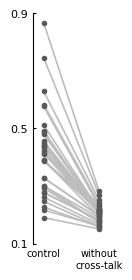

In [776]:
cpp = cm.get_cmap('binary', 256)
cp = cpp(np.linspace(0.2, 1, 33))

f, ax = plt.subplots(1, sharex=True, figsize=(1,3))
f.subplots_adjust(wspace=0.35, hspace=0.0)

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.tick_params(axis=u'y', which=u'both', length=2, direction='in', labelsize=8)
ax.tick_params(axis=u'x', which=u'both', length=0, direction='in', labelsize=8)
ax.set_xticks([0, 1])
xlabel = ['control', 'without\ncross-talk']
#ax.set_xticklabels(xlabel, va='center', ha='right', rotation=90, fontsize=7, rotation_mode='anchor')
ax.set_xticklabels(xlabel, fontsize=7)

#min0, max0 = min(res[0,:,4]), max(res[0,:,4])
#print(min0, max0)
s0 = res[0,:,4]#/max0*200

#min1, max1 = min(res[1,:,4]), max(res[1,:,4])
s1 = res[1,:,4]#/max0*200
data = np.array([s0, s1]).T
for d in data:
   # print(d)
    ax.plot([0,1], d, 'o', ms=3, lw=lw, color=cp[i], zorder=9)
    ax.plot([0,1], d, '-', lw=lw, color=cpall[-3])

ax.set_xlim(-0.2,1.2)
ax.set_yticks([0.1, 0.5, 0.9])

plt.savefig(os.path.join(figPath, 'resCaChange.eps'), fmt='eps', dpi=300,
            bbox_inches='tight', transparent=True)